In [1]:
%autosave 60

Autosaving every 60 seconds


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.convnext import ConvNeXtSmall, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import os


In [4]:
# Configs
img_size = 224
batch_size = 16
num_classes = 29  # Updated for gemstone dataset
epochs_stage1 = 12
epochs_stage2 = 15

In [5]:
# Save Paths
save_dir = '/content/drive/MyDrive/ConvNeXtSmall_Gemstone-50'
os.makedirs(save_dir, exist_ok=True)

model_best_stage1 = os.path.join(save_dir, 'convnext_gemstone_best_stage1.h5')
model_best_stage2 = os.path.join(save_dir, 'convnext_gemstone_best_stage2.h5')
history_file = os.path.join(save_dir, 'convnext_gemstone_history.json')
final_model_h5 = os.path.join(save_dir, 'convnext_gemstone_final_model.h5')
report_file = os.path.join(save_dir, 'classification_report_gemstone.txt')
misclassified_file = os.path.join(save_dir, 'misclassified_images_gemstone.txt')

In [6]:
# Data Paths (update with your actual path)
train_dir = '/content/drive/MyDrive/50-50New/Agu_50-50_Split_NewNew/train'
val_dir = '/content/drive/MyDrive/50-50New/Agu_50-50_Split_NewNew/test'

In [7]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2610 images belonging to 29 classes.
Found 2610 images belonging to 29 classes.


In [8]:
# Load ConvNeXtSmall base model
base_model = ConvNeXtSmall(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

# Add custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

198551472/198551472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
# Compile for Stage 1
model.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks_stage1 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1, monitor='val_accuracy'),
    ModelCheckpoint(filepath=model_best_stage1, monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train Stage 1
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage1,
    callbacks=callbacks_stage1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.0775 - loss: 3.4269
Epoch 1: val_accuracy improved from -inf to 0.32184, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage1.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 2185s 13s/step - accuracy: 0.0779 - loss: 3.4254 - val_accuracy: 0.3218 - val_loss: 2.6859 - learning_rate: 0.0010
Epoch 2/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.3146 - loss: 2.5614
Epoch 2: val_accuracy improved from 0.32184 to 0.48123, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage1.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 72s 437ms/step - accuracy: 0.3148 - loss: 2.5607 - val_accuracy: 0.4812 - val_loss: 2.1168 - learning_rate: 0.0010
Epoch 3/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.4338 - loss: 2.0965
Epoch 3: val_accuracy improved from 0.48123 to 0.59080, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage1.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 72s 436ms/step - accuracy: 0.4340 - loss: 2.0958 - val_accuracy: 0.5908 - val_loss: 1.7545 - learning_rate: 0.0010
Epoch 4/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.5268 - loss: 1.7367
Epoch 4: val_accuracy improved from 0.59080 to 0.63065, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage1.h5


...

164/164 ━━━━━━━━━━━━━━━━━━━━ 82s 430ms/step - accuracy: 0.6924 - loss: 1.1224 - val_accuracy: 0.7134 - val_loss: 1.0694 - learning_rate: 0.0010
Epoch 8/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.7365 - loss: 1.0287
Epoch 8: val_accuracy improved from 0.71341 to 0.74444, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage1.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 69s 423ms/step - accuracy: 0.7364 - loss: 1.0289 - val_accuracy: 0.7444 - val_loss: 0.9544 - learning_rate: 0.0010
Epoch 9/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.7321 - loss: 0.9817
Epoch 9: val_accuracy improved from 0.74444 to 0.75249, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage1.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 70s 428ms/step - accuracy: 0.7321 - loss: 0.9816 - val_accuracy: 0.7525 - val_loss: 0.9000 - learning_rate: 0.0010
Epoch 10/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.7385 - loss: 0.9172
Epoch 10: val_accuracy improved from 0.75249 to 0.77510, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage1.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 71s 428ms/step - accuracy: 0.7386 - loss: 0.9171 - val_accuracy: 0.7751 - val_loss: 0.8334 - learning_rate: 0.0010
Epoch 11/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.7540 - loss: 0.8575
Epoch 11: val_accuracy did not improve from 0.77510
164/164 ━━━━━━━━━━━━━━━━━━━━ 77s 398ms/step - accuracy: 0.7540 - loss: 0.8575 - val_accuracy: 0.7690 - val_loss: 0.8116 - learning_rate: 0.0010
Epoch 12/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.7605 - loss: 0.8195
Epoch 12: val_accuracy improved from 0.77510 to 0.79923, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage1.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 69s 423ms/step - accuracy: 0.7605 - loss: 0.8196 - val_accuracy: 0.7992 - val_loss: 0.7193 - learning_rate: 0.0010


In [10]:
# Fine-tune Stage 2
base_model.trainable = True
model.compile(optimizer=SGD(learning_rate=1e-4, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks_stage2 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1, monitor='val_accuracy'),
    ModelCheckpoint(filepath=model_best_stage2, monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train Stage 2
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage2,
    callbacks=callbacks_stage2
)

Epoch 1/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.7969 - loss: 0.7394
Epoch 1: val_accuracy improved from -inf to 0.83793, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage2.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 202s 909ms/step - accuracy: 0.7969 - loss: 0.7392 - val_accuracy: 0.8379 - val_loss: 0.5646 - learning_rate: 1.0000e-04
Epoch 2/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.8235 - loss: 0.5902
Epoch 2: val_accuracy improved from 0.83793 to 0.85594, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage2.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 130s 794ms/step - accuracy: 0.8236 - loss: 0.5900 - val_accuracy: 0.8559 - val_loss: 0.4931 - learning_rate: 1.0000e-04
Epoch 3/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.8445 - loss: 0.5229
Epoch 3: val_accuracy improved from 0.85594 to 0.87203, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage2.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 137s 836ms/step - accuracy: 0.8445 - loss: 0.5228 - val_accuracy: 0.8720 - val_loss: 0.4407 - learning_rate: 1.0000e-04
Epoch 4/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.8748 - loss: 0.4192
Epoch 4: val_accuracy improved from 0.87203 to 0.88238, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage2.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 137s 836ms/step - accuracy: 0.8748 - loss: 0.4193 - val_accuracy: 0.8824 - val_loss: 0.3968 - learning_rate: 1.0000e-04
Epoch 5/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.8681 - loss: 0.4266
Epoch 5: val_accuracy improved from 0.88238 to 0.88851, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage2.h5


...

164/164 ━━━━━━━━━━━━━━━━━━━━ 139s 850ms/step - accuracy: 0.8923 - loss: 0.3372 - val_accuracy: 0.9134 - val_loss: 0.2908 - learning_rate: 1.0000e-04
Epoch 11/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9175 - loss: 0.3009
Epoch 11: val_accuracy did not improve from 0.91341
164/164 ━━━━━━━━━━━━━━━━━━━━ 126s 770ms/step - accuracy: 0.9175 - loss: 0.3009 - val_accuracy: 0.9084 - val_loss: 0.2904 - learning_rate: 1.0000e-04
Epoch 12/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.9226 - loss: 0.2719
Epoch 12: val_accuracy improved from 0.91341 to 0.91648, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage2.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 127s 773ms/step - accuracy: 0.9226 - loss: 0.2719 - val_accuracy: 0.9165 - val_loss: 0.2755 - learning_rate: 1.0000e-04
Epoch 13/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.9158 - loss: 0.2790
Epoch 13: val_accuracy improved from 0.91648 to 0.91992, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage2.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 138s 838ms/step - accuracy: 0.9158 - loss: 0.2790 - val_accuracy: 0.9199 - val_loss: 0.2644 - learning_rate: 1.0000e-04
Epoch 14/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.9256 - loss: 0.2738
Epoch 14: val_accuracy improved from 0.91992 to 0.92337, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage2.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 135s 825ms/step - accuracy: 0.9256 - loss: 0.2738 - val_accuracy: 0.9234 - val_loss: 0.2502 - learning_rate: 1.0000e-04
Epoch 15/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.9355 - loss: 0.2372
Epoch 15: val_accuracy improved from 0.92337 to 0.92452, saving model to /content/drive/MyDrive/ConvNeXtSmall_Gemstone-50/convnext_gemstone_best_stage2.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 139s 848ms/step - accuracy: 0.9354 - loss: 0.2372 - val_accuracy: 0.9245 - val_loss: 0.2459 - learning_rate: 1.0000e-04


In [11]:
# Save final model
model.save(final_model_h5)

In [18]:
#History
total_history = {
    "accuracy": history.history['accuracy'] + fine_tune_history.history['accuracy'],
    "val_accuracy": history.history['val_accuracy'] + fine_tune_history.history['val_accuracy'],
    "loss": history.history['loss'] + fine_tune_history.history['loss'],
    "val_loss": history.history['val_loss'] + fine_tune_history.history['val_loss']
}

with open(history_file, 'w') as f:
    json.dump(total_history, f)

In [19]:
# Evaluate model
loss, acc = model.evaluate(val_generator)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%")
print(f"✅ Test Loss: {loss:.4f}")


164/164 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.9119 - loss: 0.2706

✅ Test Accuracy: 92.45%
✅ Test Loss: 0.2459


In [20]:
# Predictions & Metrics
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

report = classification_report(y_true, y_pred, target_names=class_names)
print("\n📊 Classification Report:\n", report)

with open(report_file, "w") as f:
    f.write(report)

misclassified = [
    f"{val_generator.filenames[i]} - Predicted: {class_names[y_pred[i]]}, Actual: {class_names[y_true[i]]}"
    for i in range(len(y_pred)) if y_pred[i] != y_true[i]
]

with open(misclassified_file, "w") as f:
    f.write("\n".join(misclassified))

164/164 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step

📊 Classification Report:
                  precision    recall  f1-score   support

    Alexandrite       0.96      0.83      0.89        90
       Amethyst       0.96      1.00      0.98        90
     Aquamarine       0.79      0.70      0.74        90
     Bloodstone       0.93      0.97      0.95        90
Blue Lace Agate       0.94      0.98      0.96        90
      Carnelian       0.98      1.00      0.99        90
    Chrysoberyl       0.91      0.83      0.87        90
    Chrysoprase       1.00      1.00      1.00        90
        Citrine       0.93      0.98      0.95        90
        Diamond       0.98      0.97      0.97        90
        Emerald       0.97      1.00      0.98        90
       Fluorite       0.99      0.97      0.98        90
     Garnet Red       0.73      0.96      0.83        90
      Hessonite       0.98      0.66      0.79        90
   Lapis Lazuli       0.99      0.97      0.98        90
      Malachite 

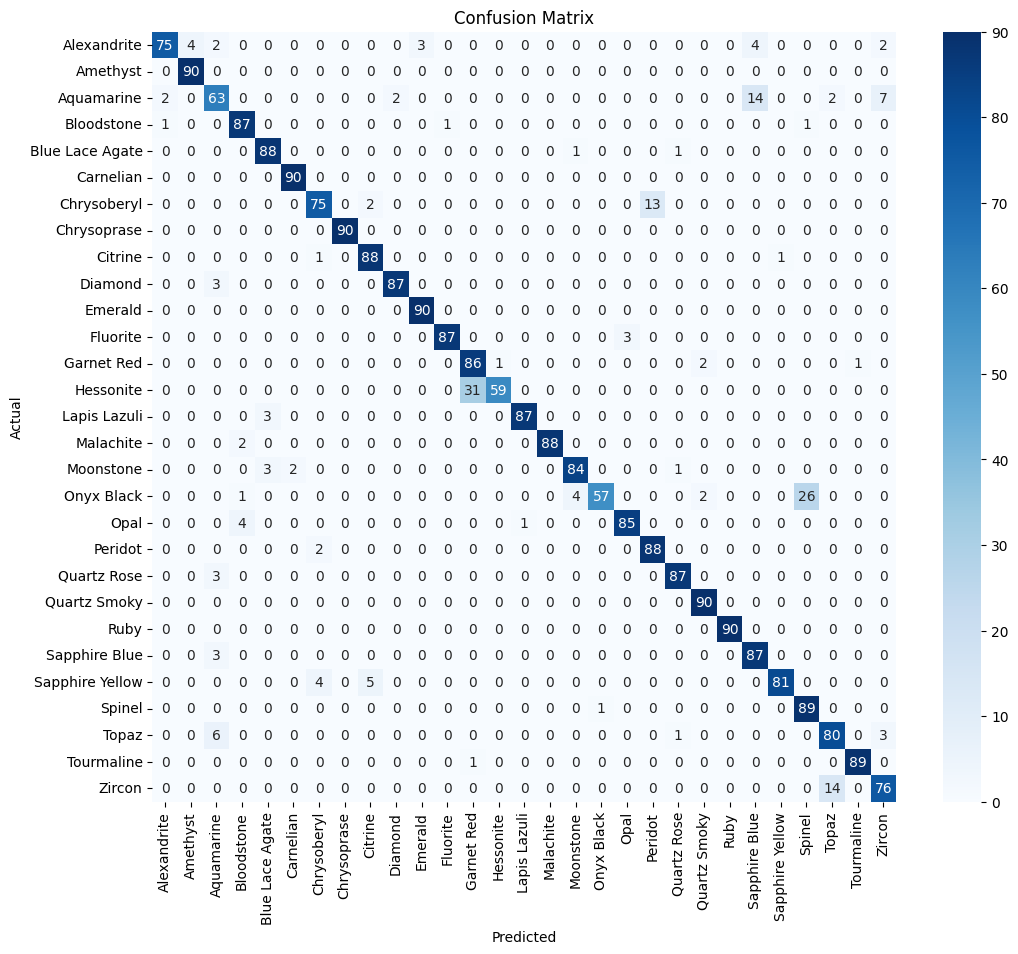

In [21]:
# Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

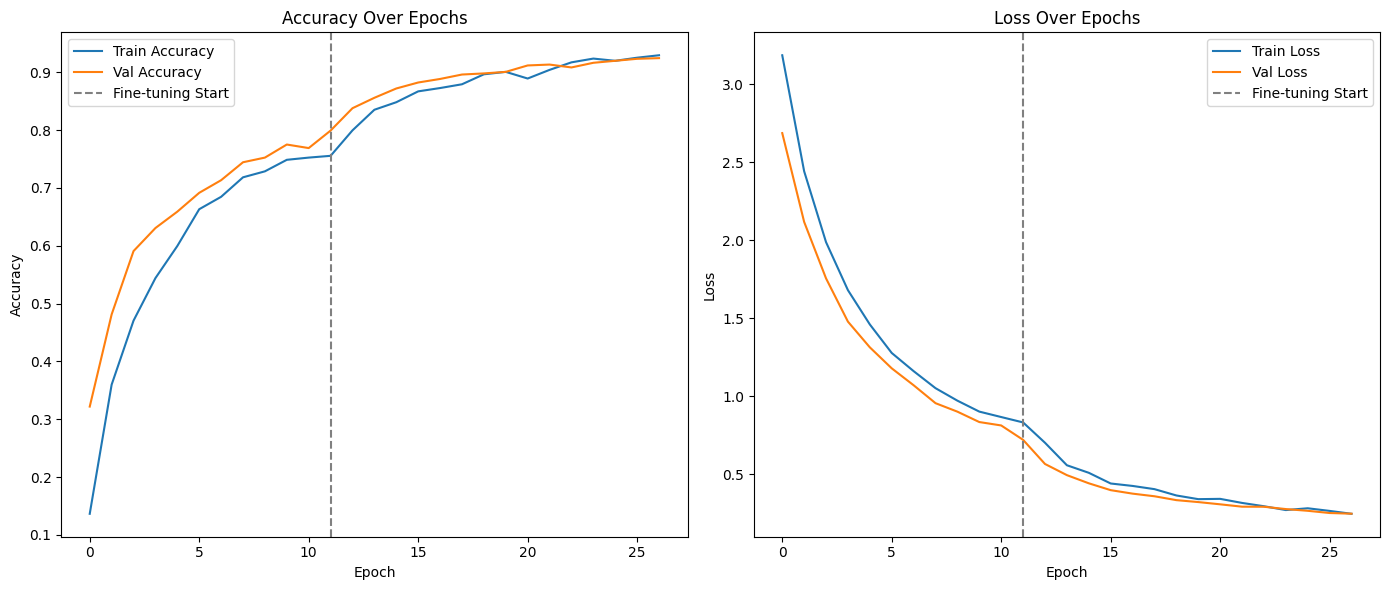

In [22]:
# Accuracy and Loss Plot
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(total_history['accuracy'], label='Train Accuracy')
plt.plot(total_history['val_accuracy'], label='Val Accuracy')
plt.axvline(x=epochs_stage1 - 1, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(total_history['loss'], label='Train Loss')
plt.plot(total_history['val_loss'], label='Val Loss')
plt.axvline(x=epochs_stage1 - 1, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()